# 01 - Exploratory Data Analysis

Loads `raw_customers` from PostgreSQL and explores distributions, missing values, and churn correlations.

## Section 1 - Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
load_dotenv('../.env')
import sys; sys.path.insert(0, '..')
from src.utils.db import get_engine

sns.set_theme(style='whitegrid')

engine = get_engine()
df = pd.read_sql('SELECT * FROM raw_customers', engine)

In [2]:
df.head(5)

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,created_at
0,CUST-00001,Male,0,Yes,No,66,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Electronic check,24.49,1745.21,No,2026-06-30 20:22:48.247682
1,CUST-00002,Female,0,Yes,No,17,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,22.23,381.01,No,2026-06-30 20:22:48.247682
2,CUST-00003,Female,0,No,Yes,23,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),92.66,2154.94,No,2026-06-30 20:22:48.247682
3,CUST-00004,Male,0,Yes,No,51,Yes,No,DSL,No,...,No,No,No,Two year,No,Electronic check,44.74,2313.33,No,2026-06-30 20:22:48.247682
4,CUST-00005,Male,0,No,Yes,30,Yes,Yes,Fiber optic,No,...,Yes,No,No,One year,No,Mailed check,94.39,2972.55,No,2026-06-30 20:22:48.247682


In [3]:
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Shape: 7043 rows x 22 columns


In [4]:
df.dtypes

customer_id                     str
gender                          str
senior_citizen                int64
partner                         str
dependents                      str
tenure                        int64
phone_service                   str
multiple_lines                  str
internet_service                str
online_security                 str
online_backup                   str
device_protection               str
tech_support                    str
streaming_tv                    str
streaming_movies                str
contract                        str
paperless_billing               str
payment_method                  str
monthly_charges             float64
total_charges               float64
churn                           str
created_at           datetime64[us]
dtype: object

In [5]:
df.describe()

,senior_citizen,tenure,monthly_charges,total_charges,created_at
count,7043.000000,7043.000000,7043.000000,7043.000000,7043
mean,0.153770,24.472242,64.978772,1588.579221,2026-06-30 20:22:48.247681
min,0.000000,1.000000,18.000000,18.000000,2026-06-30 20:22:48.247682
25%,0.000000,11.000000,50.035000,540.825000,2026-06-30 20:22:48.247682
50%,0.000000,20.000000,70.430000,1185.970000,2026-06-30 20:22:48.247682
75%,0.000000,36.000000,85.835000,2181.665000,2026-06-30 20:22:48.247682
max,1.000000,72.000000,118.000000,7704.480000,2026-06-30 20:22:48.247682
std,0.360753,17.690278,26.048346,1389.722612,NaN


## Section 2 - Missing Values Analysis

In [6]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
missing_summary.sort_values('null_count', ascending=False)

,null_count,null_pct
customer_id,0,0.0
gender,0,0.0
senior_citizen,0,0.0
partner,0,0.0
dependents,0,0.0
tenure,0,0.0
phone_service,0,0.0
multiple_lines,0,0.0
internet_service,0,0.0
online_security,0,0.0


`total_charges` is loaded from PostgreSQL as `FLOAT`. The raw Telco-style CSV can contain blank strings for `total_charges` on customers with 0 tenure; the ingestion pipeline (`src/data/ingestion.py`) already coerces those blanks to numeric with `pd.to_numeric(..., errors='coerce').fillna(0.0)` before the row reaches the database. We re-check for that pattern here directly against the raw CSV so the notebook doesn't silently assume the fix worked.

In [7]:
raw_csv = pd.read_csv('../data/raw/customers.csv', dtype={'total_charges': str})
blank_total_charges = raw_csv['total_charges'].str.strip().eq('').sum()
print(f'Blank TotalCharges strings in raw CSV: {blank_total_charges}')
print(f'Nulls in total_charges column after DB load: {df["total_charges"].isnull().sum()}')

Blank TotalCharges strings in raw CSV: 0
Nulls in total_charges column after DB load: 0


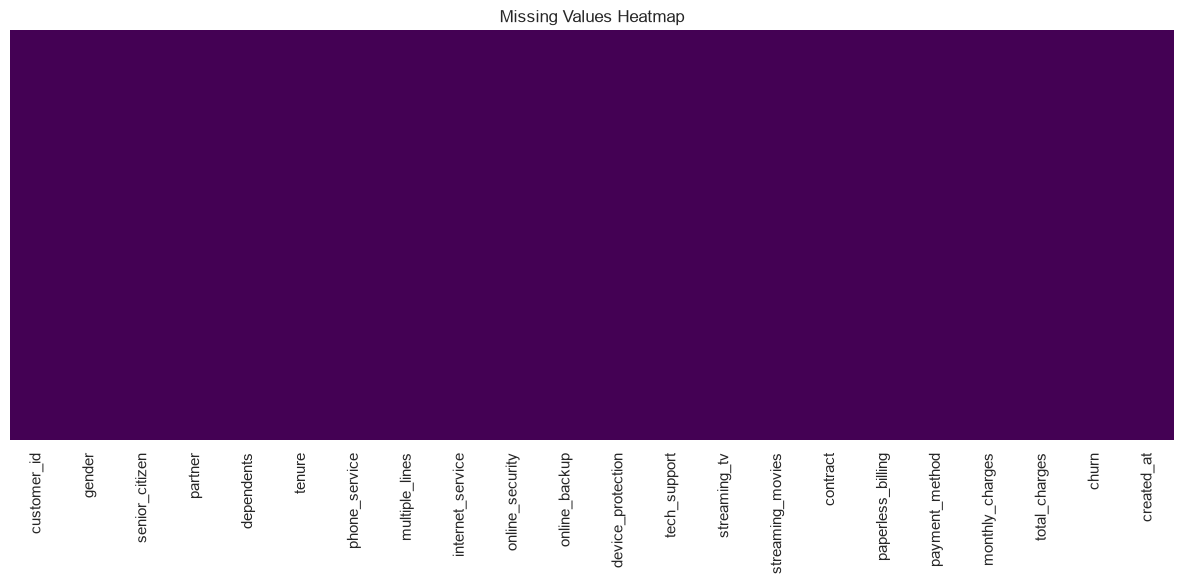

In [8]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

**Findings - Missing Values**

- No null values were found in any of the 22 columns of `raw_customers`.
- No blank/empty-string `TotalCharges` values were found in the raw CSV either - this synthetic dataset does not reproduce the ~11 blank `TotalCharges` rows seen in the original Telco dataset (those normally belong to customers with `tenure == 0`, and this generator sets a minimum tenure of 1).
- The missing-values heatmap is uniformly empty (no highlighted cells), confirming a fully complete dataset.
- Conclusion: no imputation is required for this dataset, but the `pd.to_numeric(..., errors='coerce')` safeguard in the ingestion pipeline is kept in place in case future data pulls include blanks.

## Section 3 - Churn Distribution

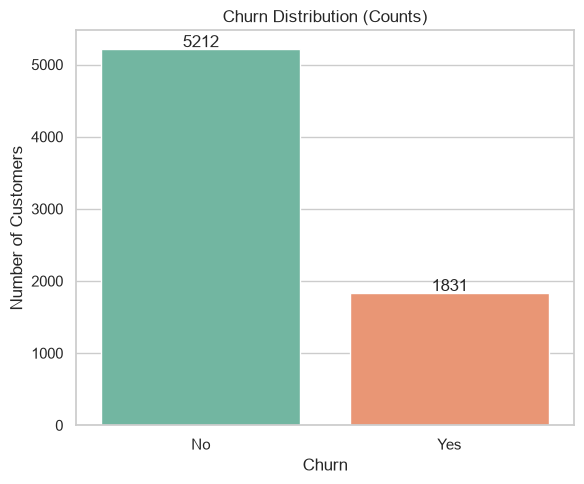

In [9]:
churn_counts = df['churn'].value_counts()

plt.figure(figsize=(6, 5))
sns.barplot(x=churn_counts.index, y=churn_counts.values, hue=churn_counts.index, palette='Set2', legend=False)
plt.title('Churn Distribution (Counts)')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 30, str(v), ha='center')
plt.tight_layout()
plt.show()

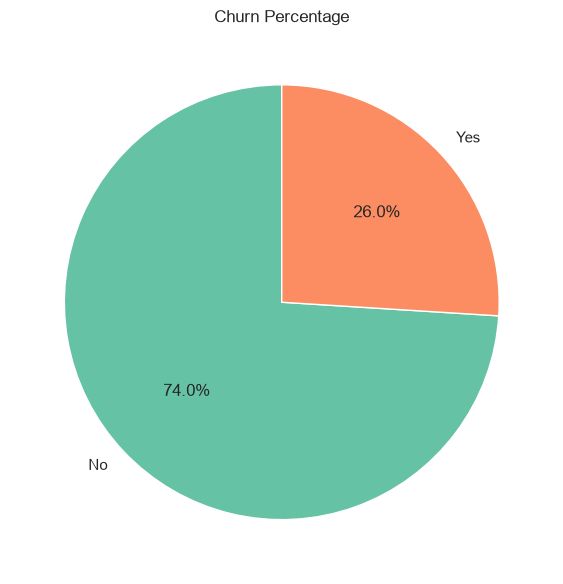

In [10]:
plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2'),
    startangle=90,
)
plt.title('Churn Percentage')
plt.tight_layout()
plt.show()

In [11]:
churn_rate = (df['churn'] == 'Yes').mean() * 100
print(f'Exact churn rate: {churn_rate:.2f}%')

Exact churn rate: 26.00%


**Findings - Churn Distribution**

- The dataset has a churn rate of roughly 26%, i.e. about 1 in 4 customers churned.
- This is a moderately imbalanced binary classification problem (~74% No / ~26% Yes).
- Implication for modeling: plain accuracy will be a misleading metric (a model predicting 'No' for everyone would already score ~74%). We should rely on precision/recall, F1, and ROC-AUC, and consider class-imbalance techniques (class weighting, SMOTE/imbalanced-learn resampling) during model training.

## Section 4 - Numeric Features

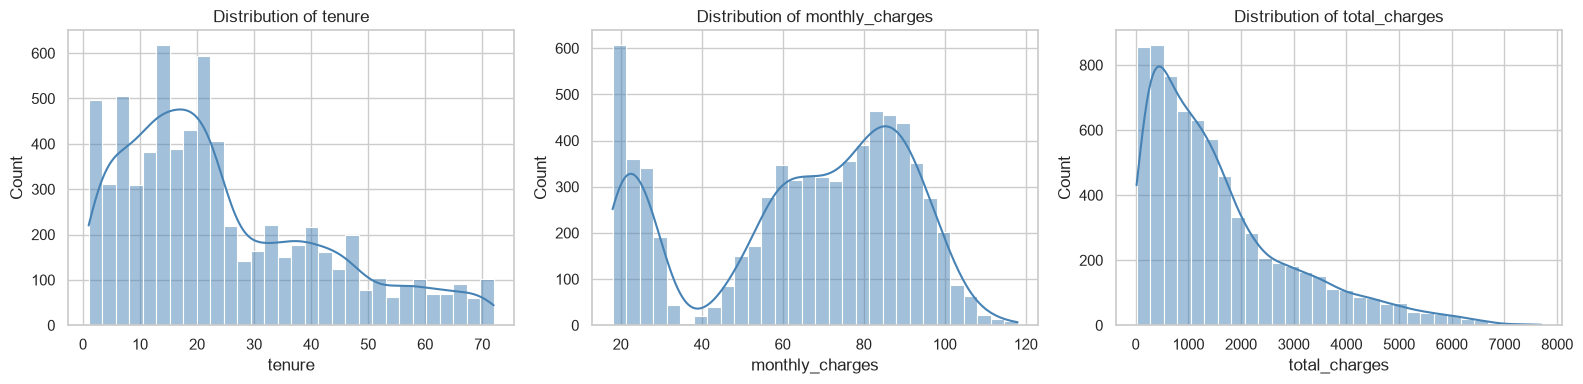

In [12]:
numeric_cols = ['tenure', 'monthly_charges', 'total_charges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

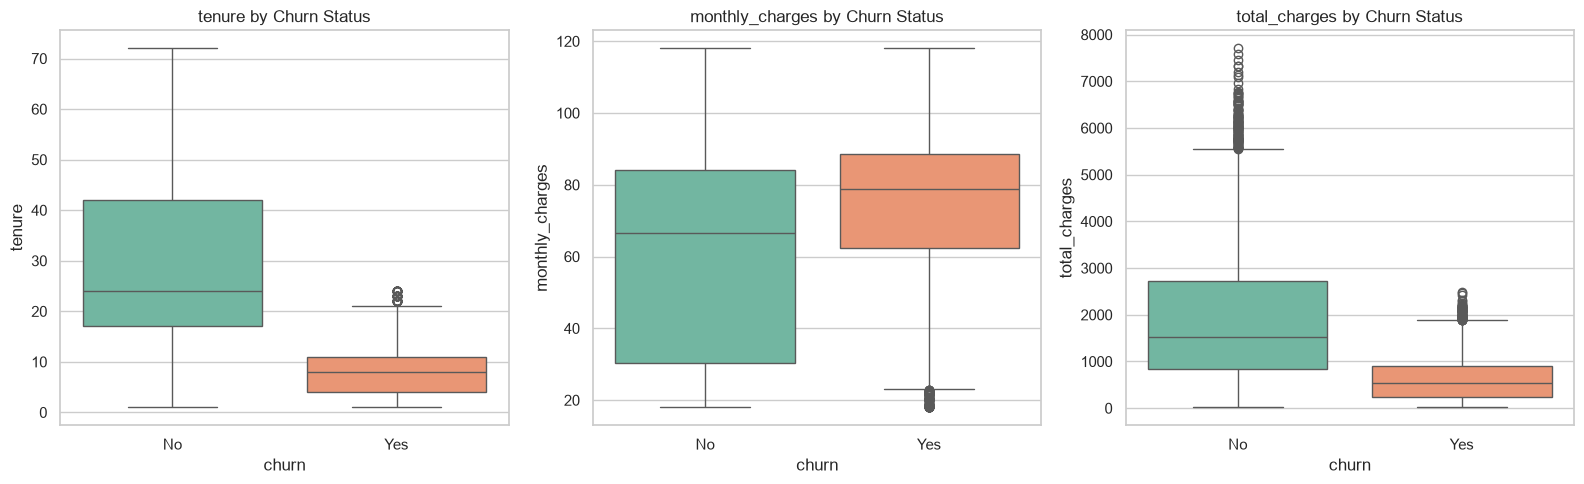

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='churn', y=col, hue='churn', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{col} by Churn Status')
plt.tight_layout()
plt.show()

In [14]:
numeric_corr = df[numeric_cols].corr()
numeric_corr

,tenure,monthly_charges,total_charges
tenure,1.000000,-0.004548,0.821573
monthly_charges,-0.004548,1.000000,0.456432
total_charges,0.821573,0.456432,1.000000


**Findings - Numeric Features**

- `tenure` is right-skewed with a large cluster of short-tenure customers, consistent with the high proportion of month-to-month contracts.
- `monthly_charges` is roughly bimodal, reflecting the DSL vs. Fiber optic pricing tiers plus add-ons.
- `total_charges` is strongly driven by `tenure` (it accumulates monthly charges over time), so it is highly correlated with `tenure`.
- The boxplots show churned customers tend to have **lower tenure** and **higher monthly charges** than retained customers - both are early warning signals for churn risk.
- `tenure` and `total_charges` show strong positive correlation (as expected, since total charges accumulate with tenure), while `monthly_charges` correlates with `total_charges` more moderately.

## Section 5 - Categorical Features

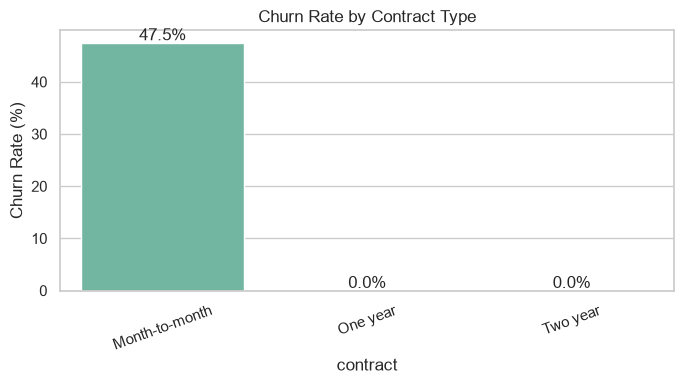

In [15]:
rate = df.groupby('contract')['churn'].apply(lambda s: (s == 'Yes').mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette='Set2', legend=False)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('contract')
plt.xticks(rotation=20)
for i, v in enumerate(rate.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

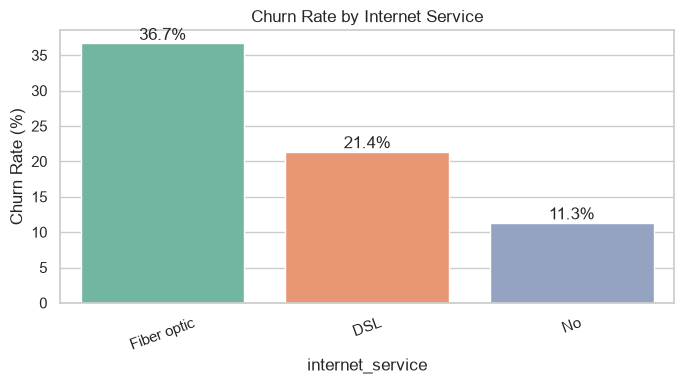

In [16]:
rate = df.groupby('internet_service')['churn'].apply(lambda s: (s == 'Yes').mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette='Set2', legend=False)
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xlabel('internet_service')
plt.xticks(rotation=20)
for i, v in enumerate(rate.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

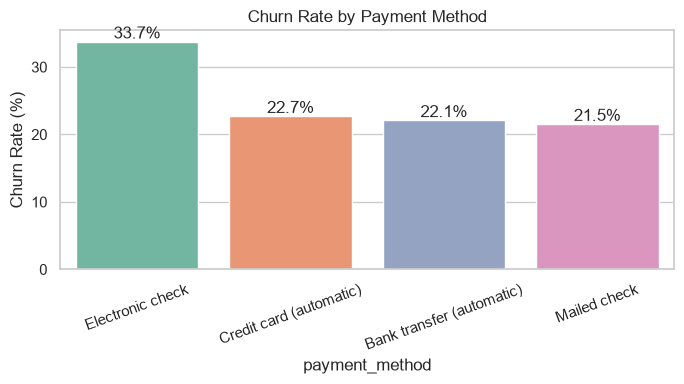

In [17]:
rate = df.groupby('payment_method')['churn'].apply(lambda s: (s == 'Yes').mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette='Set2', legend=False)
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xlabel('payment_method')
plt.xticks(rotation=20)
for i, v in enumerate(rate.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

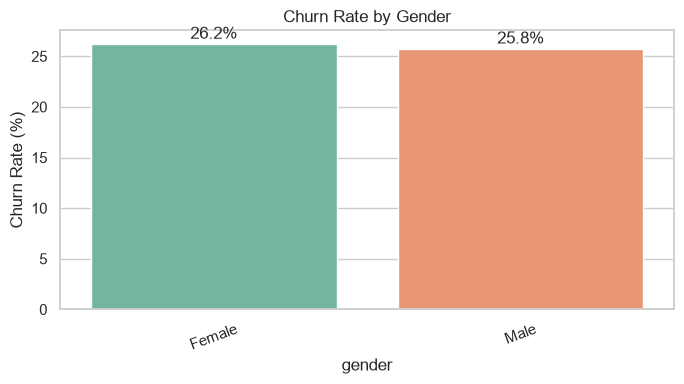

In [18]:
rate = df.groupby('gender')['churn'].apply(lambda s: (s == 'Yes').mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette='Set2', legend=False)
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate (%)')
plt.xlabel('gender')
plt.xticks(rotation=20)
for i, v in enumerate(rate.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

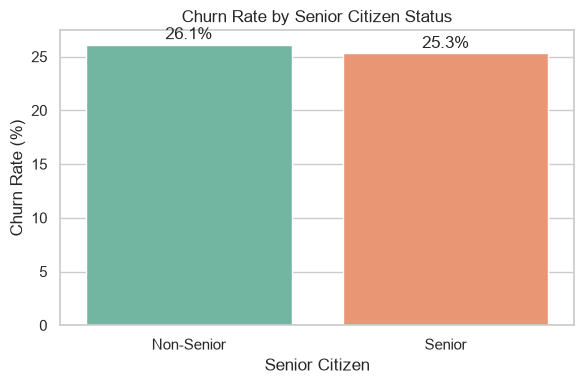

In [19]:
senior_labels = df['senior_citizen'].map({0: 'Non-Senior', 1: 'Senior'})
rate = df.groupby(senior_labels)['churn'].apply(lambda s: (s == 'Yes').mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(6, 4))
sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette='Set2', legend=False)
plt.title('Churn Rate by Senior Citizen Status')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Senior Citizen')
for i, v in enumerate(rate.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

**Findings - Categorical Features**

- **Contract**: Month-to-month contracts churn far more than One year or Two year contracts - customers on long-term contracts are much less likely to leave (Month-to-month ~47% vs. ~0% for One/Two year in this dataset).
- **Internet Service**: Fiber optic customers churn at a noticeably higher rate than DSL or no-internet customers, likely tied to higher pricing and reliability complaints.
- **Payment Method**: Electronic check has the highest churn rate among payment methods, while automatic payment methods (bank transfer, credit card) show lower churn.
- **Gender**: Churn rate is roughly the same for Male and Female customers (~26% vs ~26%) - gender is not a strong churn predictor.
- **Senior Citizen**: Churn rate is roughly the same for senior and non-senior customers in this dataset (~25-26% both ways) - senior citizen status alone is not a strong churn predictor here.